In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
path_to_data = Path(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\housing.csv')

In [3]:
df = pd.read_csv(path_to_data)

In [4]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


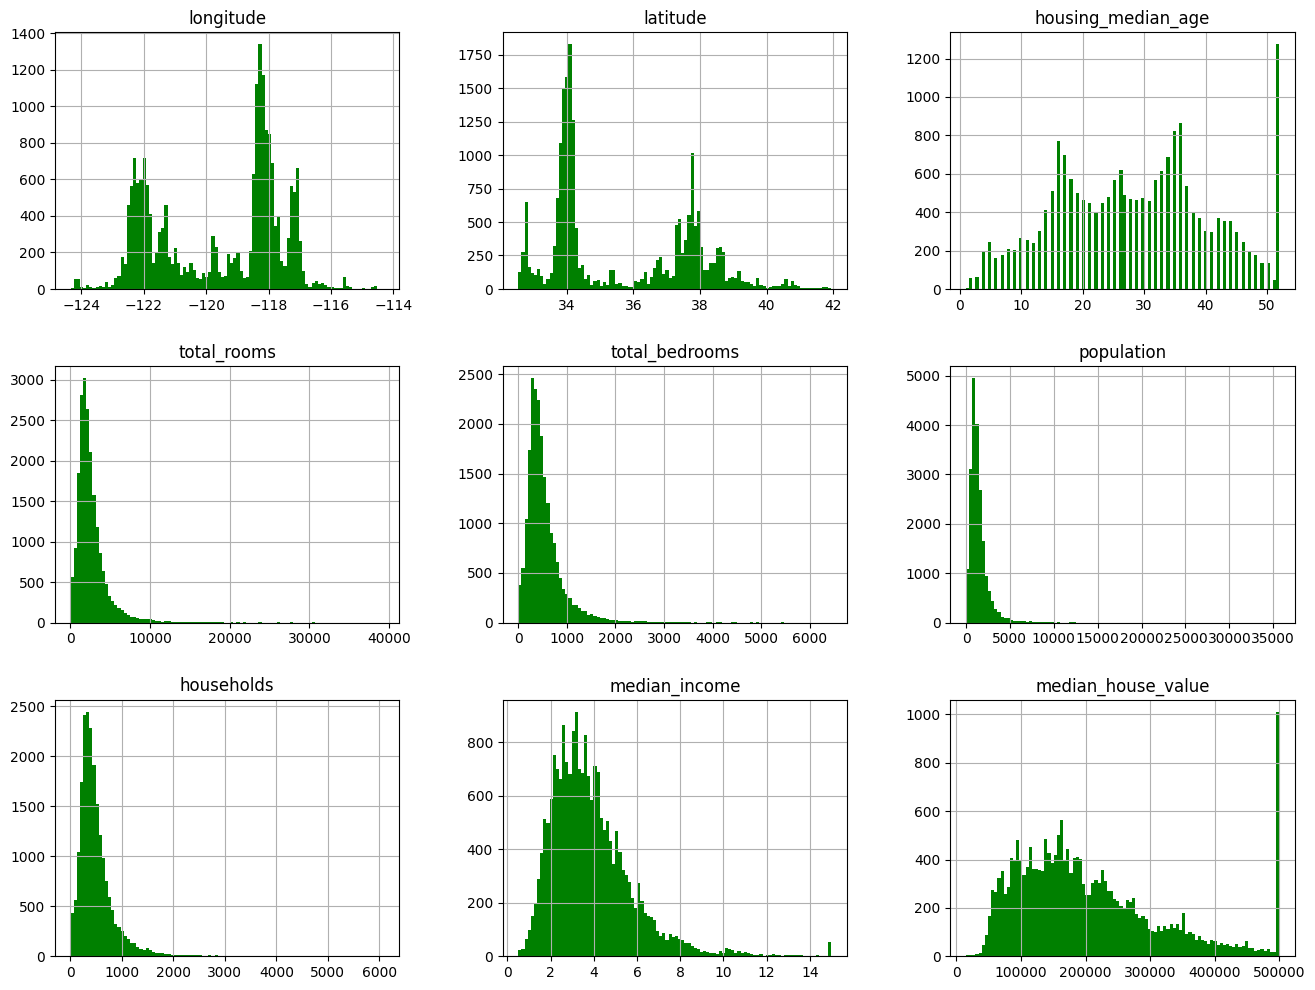

In [7]:
df.hist(bins=100, figsize=(16, 12), color='g');

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_set, test_set = train_test_split(df, test_size=0.2)

In [10]:
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2627,-118.36,33.93,40.0,1625.0,500.0,2036.0,476.0,2.6298,156500.0,<1H OCEAN
597,-120.98,39.93,25.0,2220.0,511.0,912.0,449.0,1.8914,87800.0,INLAND
17035,-118.94,35.37,23.0,1106.0,252.0,790.0,230.0,1.8523,59700.0,INLAND
17115,-121.99,37.30,28.0,4863.0,901.0,2110.0,868.0,5.1483,342000.0,<1H OCEAN
15063,-117.25,33.03,6.0,3416.0,493.0,1319.0,467.0,6.9326,324600.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
909,-118.60,34.07,16.0,319.0,59.0,149.0,64.0,4.6250,433300.0,<1H OCEAN
20333,-121.95,37.26,34.0,1482.0,255.0,584.0,246.0,5.5121,264700.0,<1H OCEAN
6803,-118.37,33.88,26.0,2620.0,530.0,1282.0,525.0,4.4828,340700.0,<1H OCEAN
4879,-122.07,37.52,3.0,14014.0,2861.0,7205.0,2753.0,6.0824,273500.0,NEAR BAY


In [11]:
df['income_cal'] = pd.cut(df['median_income'], bins=[0, 1.5, 3, 4.5, 6, np.inf], labels=[1, 2, 3, 4, 5])

In [12]:
df[['income_cal', 'median_income']]

,income_cal,median_income
0,5,8.3252
1,5,8.3014
2,5,7.2574
3,4,5.6431
4,3,3.8462
...,...,...
20635,2,1.5603
20636,2,2.5568
20637,2,1.7000
20638,2,1.8672


<Axes: xlabel='income_cal'>

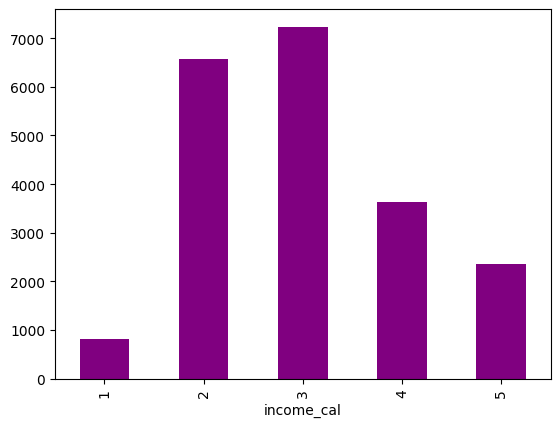

In [13]:
ic = df['income_cal'].value_counts().sort_index()
ic.plot.bar(color='purple')

In [14]:
ic / len(train_set) * 100

income_cal
1     4.978198
2    39.855862
3    43.822674
4    22.038517
5    14.304748
Name: count, dtype: float64

In [15]:
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2, stratify=df['income_cal'])

<Axes: xlabel='income_cal'>

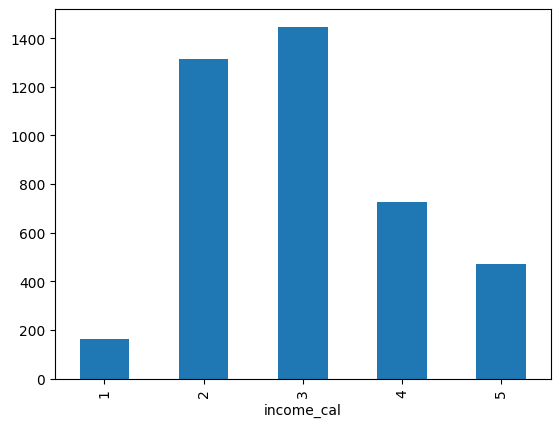

In [16]:
(
    strat_test_set['income_cal'].value_counts().sort_index().plot.bar()
)

In [17]:
import plotly.express as px

fig = px.scatter_map(
    df, 
	'latitude', 
    'longitude', 
    color='median_house_value',
    color_continuous_scale='jet',
    size='population'
    )
fig.update_layout(margin={
		'l':0, 
		'r':0, 
		't':0, 
		'b':0, 
	},
	width=800
)

In [18]:
df.select_dtypes(include='number')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [19]:
corr_matrix = df.corr(numeric_only=True)   # this produces values between 0 and 1 depending on the dependencies of cols on each other

In [20]:
corr_matrix['median_house_value'].sort_values()

latitude             -0.144160
longitude            -0.045967
population           -0.024650
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64

# Correlation

In [21]:
mhv_mean = df['median_house_value'].mean()
l_mean = df['latitude'].mean()


nominator = (
    (df['median_house_value'] - mhv_mean)
    *
    (df['latitude'] - l_mean)
).sum()

x = ((df['median_house_value'] - mhv_mean) ** 2).sum()
y = ((df['latitude'] - l_mean) ** 2).sum()

dominator = (
    np.sqrt(x * y)
)

nominator / dominator

np.float64(-0.14416027687465927)

In [22]:
import plotly.express as px

px.imshow(
    corr_matrix
)

In [23]:
import plotly.express as px

fig = px.imshow(
    corr_matrix, 
    color_continuous_scale='RdBu', 
    text_auto=".2f",
	aspect='auto'
)
fig.update_layout(margin={
		't':0, 
		'b':0, 
	},
	width=700
)

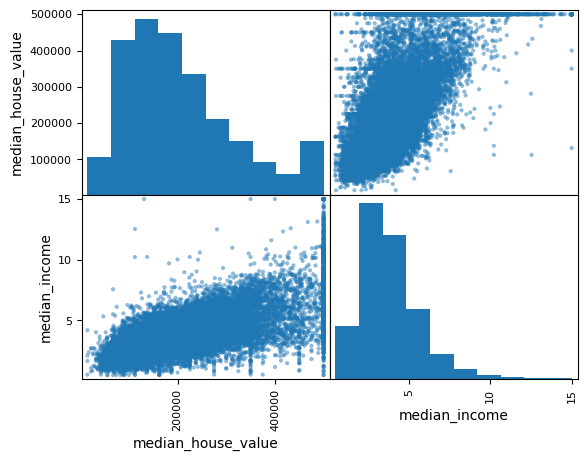

In [24]:
from pandas.plotting import scatter_matrix

cols = ['median_house_value', 'median_income']

scatter_matrix(df[cols]);

In [25]:
px.scatter(
    df, 
    'median_house_value',
    'median_income'
)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  object  
 10  income_cal          20640 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.6+ MB


In [27]:
df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

In [28]:
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2627,-118.36,33.93,40.0,1625.0,500.0,2036.0,476.0,2.6298,156500.0,<1H OCEAN
597,-120.98,39.93,25.0,2220.0,511.0,912.0,449.0,1.8914,87800.0,INLAND
17035,-118.94,35.37,23.0,1106.0,252.0,790.0,230.0,1.8523,59700.0,INLAND
17115,-121.99,37.30,28.0,4863.0,901.0,2110.0,868.0,5.1483,342000.0,<1H OCEAN
15063,-117.25,33.03,6.0,3416.0,493.0,1319.0,467.0,6.9326,324600.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
909,-118.60,34.07,16.0,319.0,59.0,149.0,64.0,4.6250,433300.0,<1H OCEAN
20333,-121.95,37.26,34.0,1482.0,255.0,584.0,246.0,5.5121,264700.0,<1H OCEAN
6803,-118.37,33.88,26.0,2620.0,530.0,1282.0,525.0,4.4828,340700.0,<1H OCEAN
4879,-122.07,37.52,3.0,14014.0,2861.0,7205.0,2753.0,6.0824,273500.0,NEAR BAY


In [29]:
df_numeric = df.select_dtypes(include='number')
df_cat = df.select_dtypes(include='object')

In [30]:
null_mask = df_numeric.isna().any(axis=1)

In [31]:
df_numeric.loc[null_mask].head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
182,-118.27,34.04,13.0,1784.0,NaN,2158.0,682.0,1.7038,118100.0
327,-117.65,34.04,15.0,3393.0,NaN,2039.0,611.0,3.9336,151000.0
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,271800.0


In [32]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
imp.fit(df_numeric)
#imp.statistics_
X = imp.transform(X=df_numeric)

df_num_tr = pd.DataFrame(X, columns=imp.get_feature_names_out())

In [33]:
df_num_tr.loc[null_mask]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
182,-118.27,34.04,13.0,1784.0,435.0,2158.0,682.0,1.7038,118100.0
327,-117.65,34.04,15.0,3393.0,435.0,2039.0,611.0,3.9336,151000.0
366,-122.50,37.75,44.0,1819.0,435.0,1137.0,354.0,3.4919,271800.0
477,-117.99,34.14,30.0,2346.0,435.0,1988.0,474.0,2.5625,153000.0
495,-114.59,34.83,41.0,812.0,435.0,375.0,158.0,1.7083,48500.0
...,...,...,...,...,...,...,...,...,...
19880,-118.23,33.94,36.0,1110.0,435.0,1417.0,302.0,2.3333,92100.0
19952,-119.19,34.20,18.0,3620.0,435.0,3171.0,779.0,3.3409,220500.0
20088,-119.73,36.83,8.0,3602.0,435.0,1959.0,580.0,5.3478,138800.0
20325,-118.88,34.17,15.0,4260.0,435.0,1701.0,669.0,5.1033,410700.0


In [34]:
df_num_tr.loc[9976]

longitude               -117.1500
latitude                  32.7200
housing_median_age        51.0000
total_rooms             1321.0000
total_bedrooms           435.0000
population               781.0000
households               499.0000
median_income              1.3071
median_house_value    250000.0000
Name: 9976, dtype: float64

In [35]:
help(SimpleImputer)

Help on class SimpleImputer in module sklearn.impute._base:

class SimpleImputer(_BaseImputer)
 |  SimpleImputer(*, missing_values=nan, strategy='mean', fill_value=None, copy=True, add_indicator=False, keep_empty_features=False)
 |  
 |  Univariate imputer for completing missing values with simple strategies.
 |  
 |  Replace missing values using a descriptive statistic (e.g. mean, median, or
 |  most frequent) along each column, or using a constant value.
 |  
 |  Read more in the :ref:`User Guide <impute>`.
 |  
 |  .. versionadded:: 0.20
 |     `SimpleImputer` replaces the previous `sklearn.preprocessing.Imputer`
 |     estimator which is now removed.
 |  
 |  Parameters
 |  ----------
 |  missing_values : int, float, str, np.nan, None or pandas.NA, default=np.nan
 |      The placeholder for the missing values. All occurrences of
 |      `missing_values` will be imputed. For pandas' dataframes with
 |      nullable integer dtypes with missing values, `missing_values`
 |      can be 

In [36]:
from sklearn.impute import KNNImputer
kimp = KNNImputer(n_neighbors=10)
kimp.fit(df_numeric)
X_num = kimp.transform(df_numeric)

In [37]:
import decimal
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(df_numeric)
X = ss.transform(df_numeric)

df_num_ss = pd.DataFrame(X, columns=ss.get_feature_names_out())

df_num_ss.describe().round(decimals=2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.39,-1.45,-2.20,-1.21,-1.27,-1.26,-1.30,-1.77,-1.66
25%,-1.11,-0.80,-0.85,-0.54,-0.57,-0.56,-0.57,-0.69,-0.76
50%,0.54,-0.64,0.03,-0.23,-0.24,-0.23,-0.24,-0.18,-0.24
75%,0.78,0.97,0.66,0.23,0.26,0.26,0.28,0.46,0.50
max,2.63,2.96,1.86,16.82,14.02,30.25,14.60,5.86,2.54


In [38]:
o1 = (df_num_ss < -3).any(axis=1)
o2 = (df_num_ss > 3).any(axis=1)

In [39]:
from sklearn.ensemble import IsolationForest

In [42]:
iso_forest = IsolationForest()
iso_forest.fit(df_numeric)
predict = iso_forest.predict(df_numeric)
predict

array([-1, -1,  1, ...,  1,  1,  1], shape=(20640,))

In [43]:
np.unique_counts(predict)

UniqueCountsResult(values=array([-1,  1]), counts=array([ 2409, 18231]))